# Exploración — Resultados internacionales de fútbol

Se explora el dataset local `data/results.csv`. El objetivo posterior será predecir el resultado antes del partido.

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
DATA_PATH = Path('data/results.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('../data/results.csv')

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
print(f'Dataset: {DATA_PATH.resolve()}')
print(f'Filas: {len(df):,} | Columnas: {df.shape[1]}')
df.head()

Dataset: C:\renzo\proyectoreal\data\results.csv
Filas: 49,547 | Columnas: 9


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [7]:
required = {'date','home_team','away_team','home_score','away_score','tournament','city','country','neutral'}
assert not required - set(df.columns), f'Faltan: {required - set(df.columns)}'
before = len(df)
df = df.drop_duplicates().dropna(subset=list(required)).copy()
df['home_score'] = pd.to_numeric(df['home_score'], errors='raise')
df['away_score'] = pd.to_numeric(df['away_score'], errors='raise')
df['neutral'] = df['neutral'].astype(str).str.upper().eq('TRUE')
df = df.sort_values('date').reset_index(drop=True)
print(f'Rango: {df.date.min().date()} a {df.date.max().date()}')
print(f'Duplicados/nulos eliminados: {before - len(df):,}')
display(df.isna().sum().to_frame('nulos'))
df.describe(include='all')

Rango: 1872-11-30 a 2026-08-26
Duplicados/nulos eliminados: 0


,nulos
date,0
home_team,0
away_team,0
home_score,0
away_score,0
tournament,0
city,0
country,0
neutral,0


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
count,49547,49547,49547,49547.000000,49547.000000,49547,49547,49547,49547
unique,NaN,328,322,NaN,NaN,202,2093,269,2
top,NaN,Brazil,Uruguay,NaN,NaN,Friendly,Kuala Lumpur,United States,False
freq,NaN,618,585,NaN,NaN,18385,748,1585,36389
mean,1994-06-07 16:43:07.216178,NaN,NaN,1.757140,1.182715,NaN,NaN,NaN,NaN
min,1872-11-30 00:00:00,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,1980-09-18 00:00:00,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN
50%,2000-07-28 00:00:00,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN
75%,2013-08-14 00:00:00,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN
max,2026-08-26 00:00:00,NaN,NaN,31.000000,21.000000,NaN,NaN,NaN,NaN


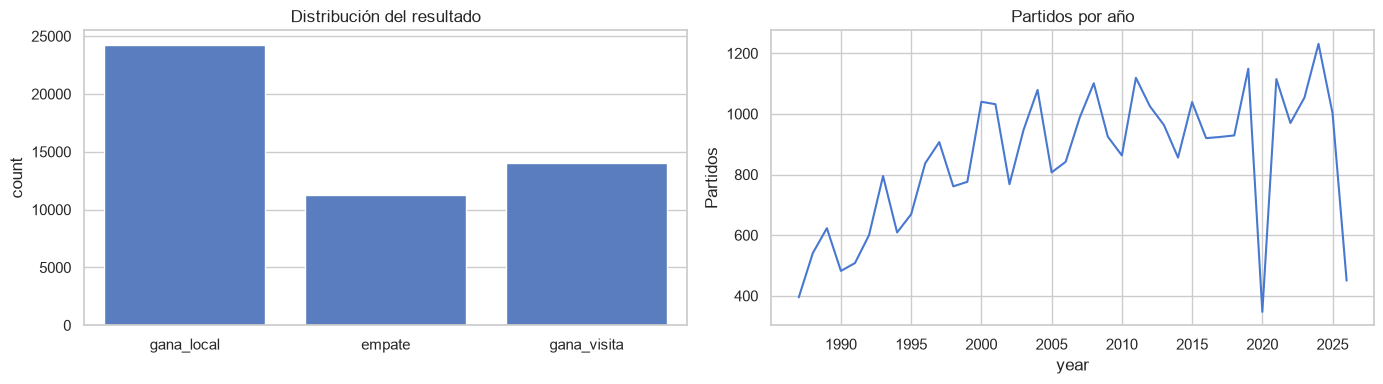

Equipos únicos: 337
Torneos únicos: 202
Sede neutral: 26.6%


In [8]:
# El objetivo se obtiene de los goles. Los goles NO serán variables predictoras.
df['resultado'] = np.select(
    [df.home_score > df.away_score, df.home_score < df.away_score],
    ['gana_local', 'gana_visita'], default='empate'
)
df['year'] = df.date.dt.year
df['month'] = df.date.dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=df, x='resultado', order=['gana_local','empate','gana_visita'], ax=axes[0])
axes[0].set_title('Distribución del resultado')
axes[0].set_xlabel('')
df.groupby('year').size().tail(40).plot(ax=axes[1], title='Partidos por año')
axes[1].set_ylabel('Partidos')
plt.tight_layout()
plt.show()

print(f'Equipos únicos: {pd.concat([df.home_team, df.away_team]).nunique()}')
print(f'Torneos únicos: {df.tournament.nunique()}')
print(f'Sede neutral: {df.neutral.mean():.1%}')

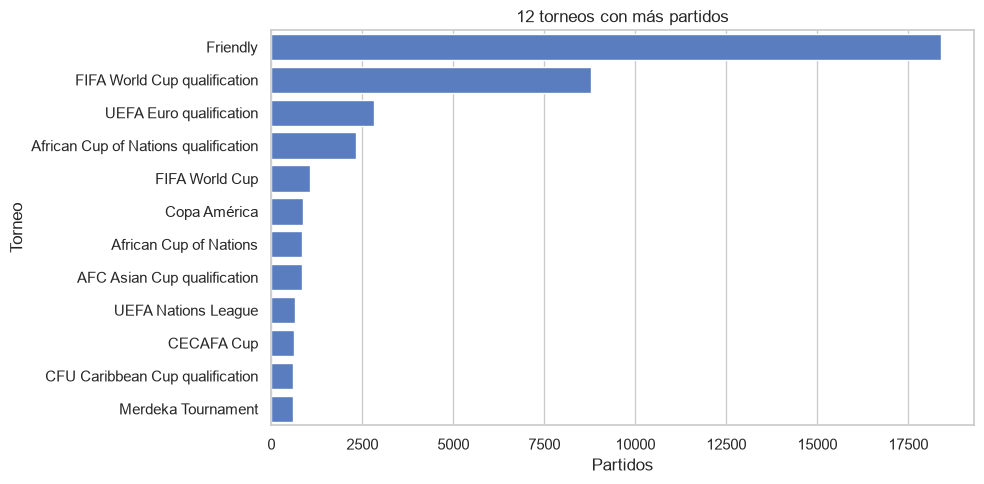

In [9]:
top = df.tournament.value_counts().head(12)
ax = sns.barplot(x=top.values, y=top.index)
ax.set(title='12 torneos con más partidos', xlabel='Partidos', ylabel='Torneo')
plt.tight_layout()
plt.show()

## Decisiones para el modelado

Se usarán equipos, torneo, país/ciudad sede, sede neutral y fecha. Se excluyen `home_score` y `away_score` porque revelan el resultado. El test será cronológico: se entrena con el pasado y se evalúa en los partidos más recientes.